# Business Understanding

## Project Domain

Domain: Environmental Science & Disaster Management

Deteksi dan prediksi banjir adalah aspek penting dalam manajemen bencana yang melibatkan identifikasi, pemantauan, dan pemberitahuan kepada pihak berwenang atau individu tentang adanya atau kemungkinan terjadinya banjir di suatu area. Dengan memanfaatkan teknologi dan metodologi canggih, model prediksi banjir dapat mengantisipasi peristiwa banjir, memungkinkan intervensi dan kesiapsiagaan yang tepat waktu. Sistem ini bertujuan untuk meningkatkan strategi respons bencana, melindungi nyawa manusia, infrastruktur, dan mengurangi dampak lingkungan dari banjir.

## Problem Statements

1. Kurangnya Sistem Peringatan Dini

Banyak daerah yang belum memiliki sistem deteksi banjir yang efektif, yang menyebabkan keterlambatan dalam respons dan ketidakmampuan untuk mencegah akibat buruk dari banjir.

2. Prediksi yang Tidak Akurat atau Terlambat

Model prediksi banjir yang ada mungkin tidak cukup akurat atau tepat waktu, seringkali hanya bergantung pada data historis tanpa mengintegrasikan faktor lingkungan secara real-time, sehingga peluang untuk tindakan pencegahan terlewatkan.

3. Dampak pada Nyawa Manusia dan Infrastruktur

Banjir menyebabkan kerugian besar terhadap nyawa manusia, kerusakan infrastruktur, dan kehancuran lingkungan. Tanpa sistem prediksi dan peringatan yang tepat, risiko banjir tetap dikelola dengan buruk.

4. Sumber Daya Terbatas untuk Mitigasi Banjir

Keterbatasan sumber daya di daerah rawan banjir sering kali menghambat pihak berwenang dalam menerapkan strategi mitigasi banjir yang tepat dan langkah-langkah kesiapsiagaan, memperburuk dampak keseluruhan dari banjir.



## Goals

Mengembangkan Sistem Prediksi Banjir Berbasis AI:
Membangun sistem menggunakan pembelajaran mesin untuk memprediksi risiko banjir berdasarkan berbagai parameter seperti curah hujan, level air, dan faktor lingkungan lainnya.

Model ini bertujuan untuk memprediksi banjir dengan akurasi tinggi, memberikan peringatan dini untuk wilayah yang berisiko.

## Solution Statements

Model Deteksi Banjir (Pembelajaran Mesin)

Implementasikan model pembelajaran mesin yang menganalisis data lingkungan, seperti curah hujan, level sungai, dan topografi, untuk memprediksi kemungkinan terjadinya banjir.

Fokus pada pencapaian akurasi tinggi dalam prediksi untuk meningkatkan sistem peringatan dini banjir dan kesiapsiagaan bencana.

Integrasi Data Real-Time

Kembangkan sistem integrasi data real-time yang terus memantau dan memproses variabel lingkungan, memungkinkan prediksi risiko banjir secara langsung dan pemberitahuan tepat waktu kepada pihak berwenang dan masyarakat.

Sistem Peringatan Web dan Mobile

Bangun aplikasi web dan mobile yang memberikan informasi dan peringatan risiko banjir secara real-time kepada pengguna, membantu pihak berwenang merespons dengan cepat dan masyarakat mengambil tindakan pencegahan yang diperlukan.

# Data Understanding

## Import data dari kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"farhanfahr","key":"05d7a6397b5486d8062c63d1132c0cee"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [4]:
!kaggle datasets download -d naiyakhalid/flood-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/naiyakhalid/flood-prediction-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/680k [00:00<?, ?B/s]
100% 680k/680k [00:00<00:00, 151MB/s]


In [5]:
!mkdir flood-prediction-dataset
!unzip flood-prediction-dataset.zip -d flood-prediction-dataset
!ls flood-prediction-dataset

Archive:  flood-prediction-dataset.zip
  inflating: flood-prediction-dataset/flood.csv  
flood.csv


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [7]:
df = pd.read_csv('flood-prediction-dataset/flood.csv')

In [8]:
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

<Axes: >

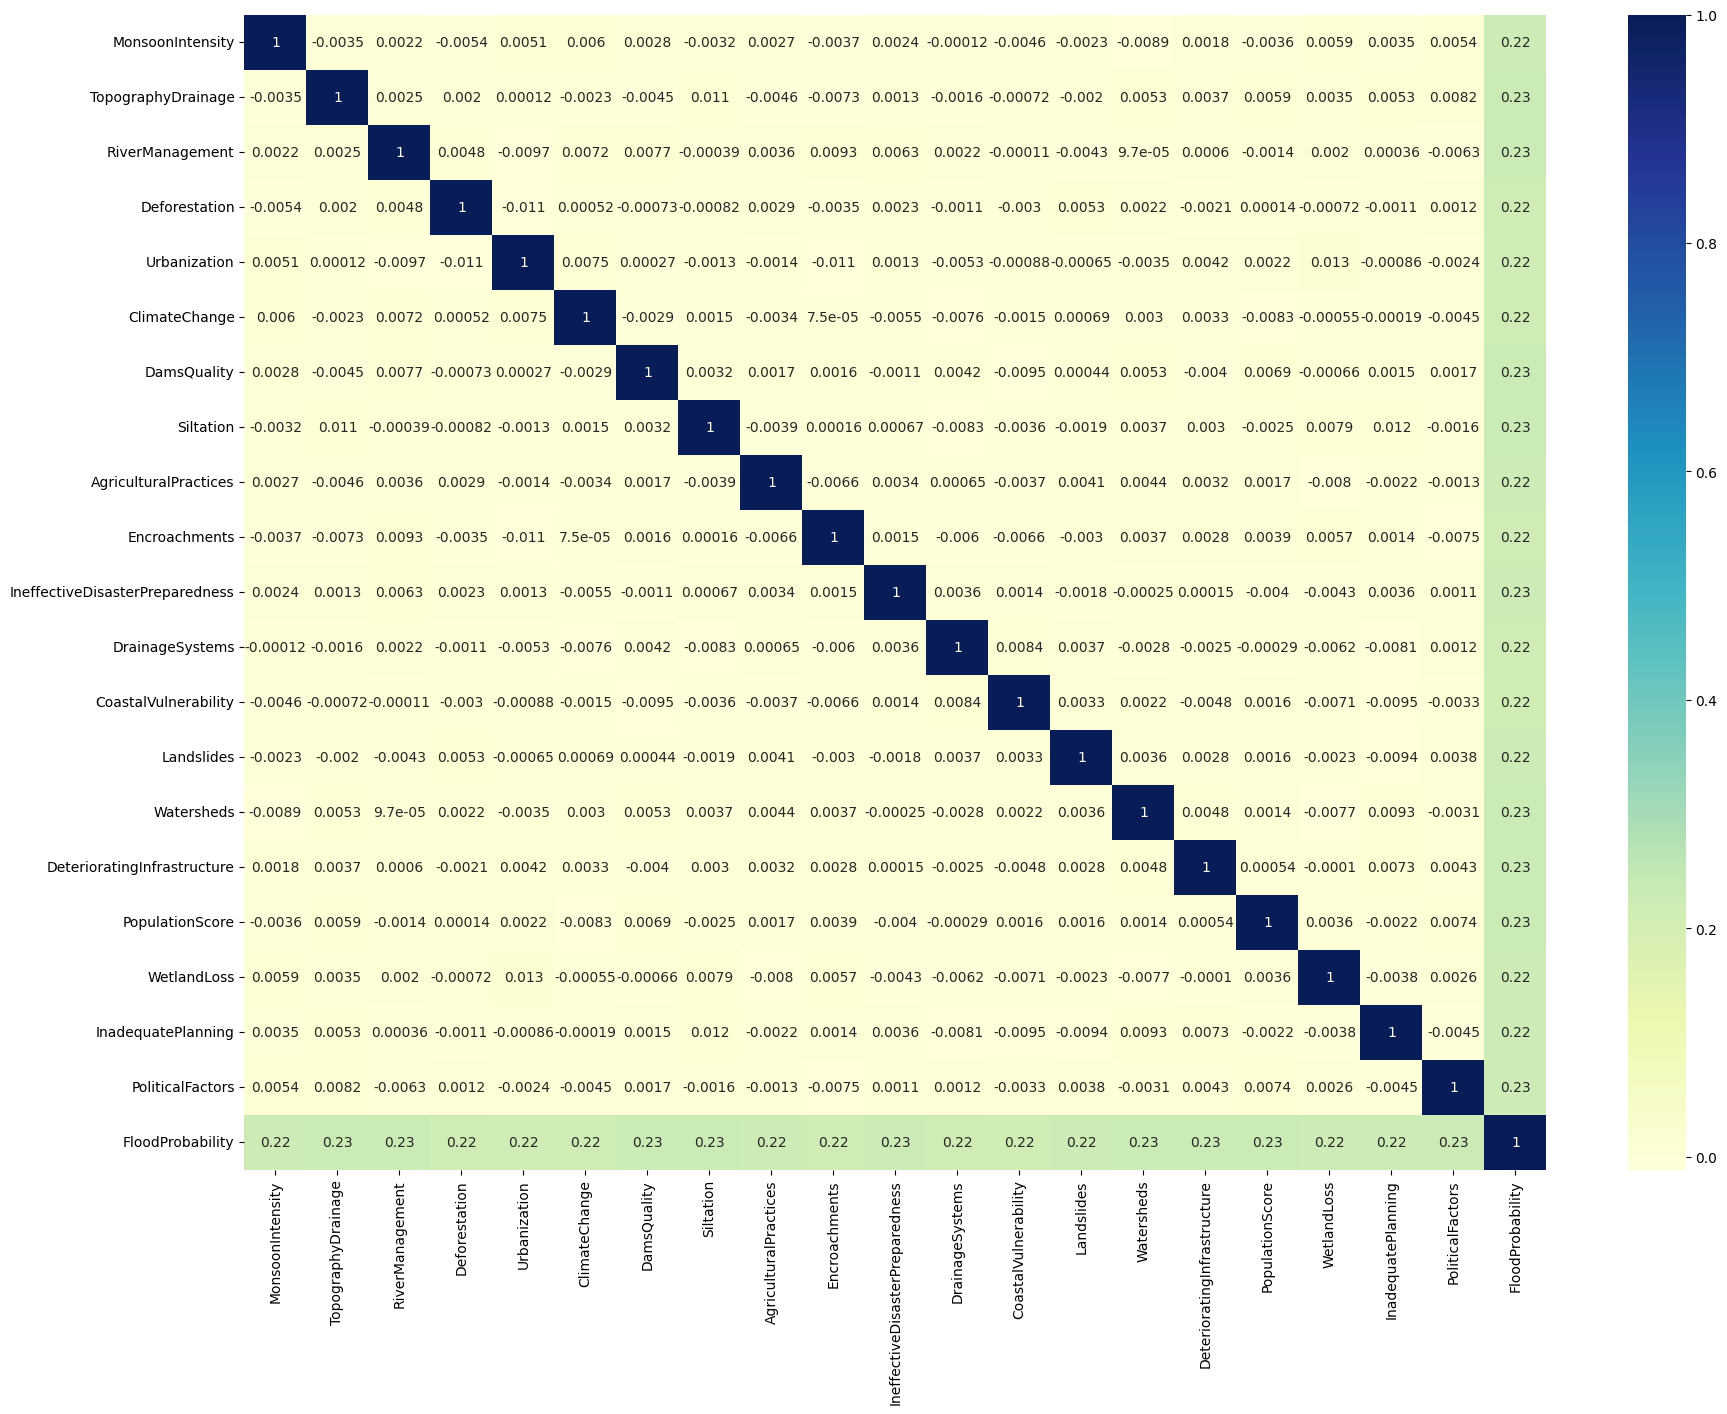

In [37]:
plt.figure(figsize=(21,15))
sns.heatmap(data=df.corr(), annot=True, cmap="YlGnBu")

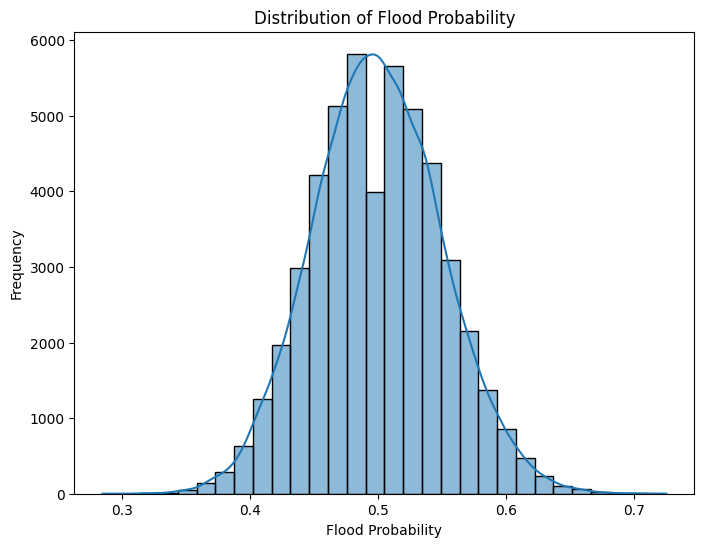

In [42]:
plt.figure(figsize=(8, 6))
sns.histplot(df['FloodProbability'], kde=True, bins=30)
plt.title('Distribution of Flood Probability')
plt.xlabel('Flood Probability')
plt.ylabel('Frequency')
plt.show()

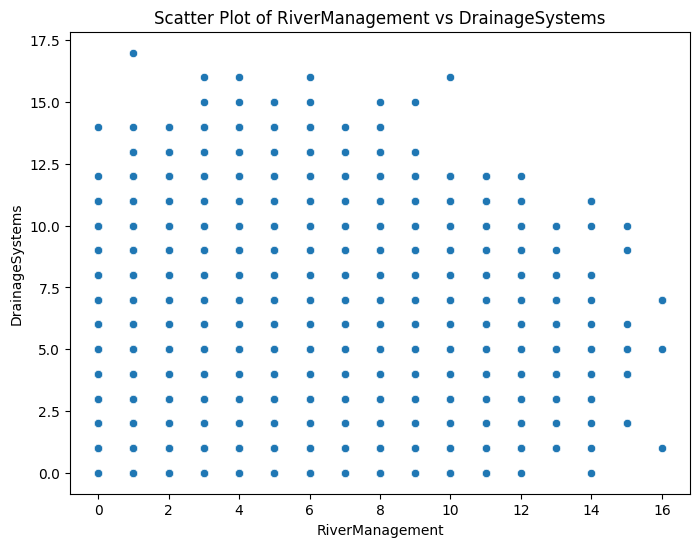

In [60]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='RiverManagement', y='DrainageSystems', data=df)
plt.title('Scatter Plot of RiverManagement vs DrainageSystems')
plt.xlabel('RiverManagement')
plt.ylabel('DrainageSystems')
plt.show()

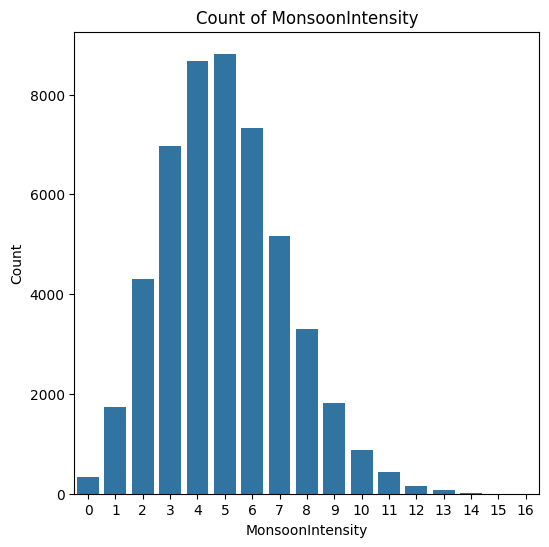

In [67]:
plt.figure(figsize=(6, 6))

sns.countplot(x='MonsoonIntensity', data=df)

plt.title('Count of MonsoonIntensity')

plt.xlabel('MonsoonIntensity')

plt.ylabel('Count')

plt.show()

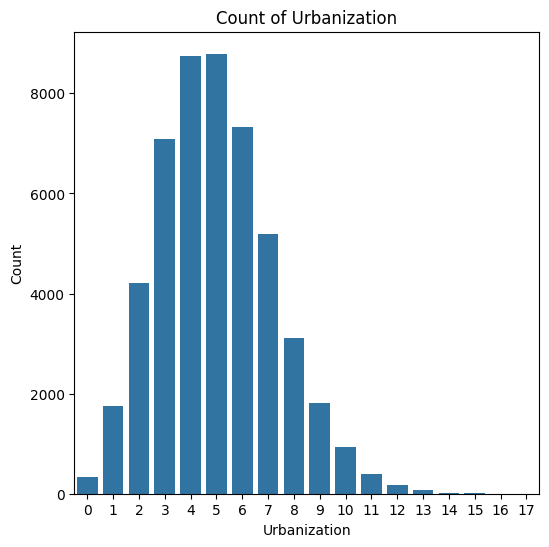

In [68]:
plt.figure(figsize=(6, 6))

sns.countplot(x='Urbanization', data=df)

plt.title('Count of Urbanization')

plt.xlabel('Urbanization')

plt.ylabel('Count')

plt.show()

# Data Preparation

In [11]:
X = df.drop(columns=["FloodProbability"])
y = df["FloodProbability"]

In [12]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [13]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [20]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [21]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 83)                  │           2,739 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,763 (61.57 KB)

 Trainable params: 15,763 (61.57 KB)

 Non-trainable params: 0 (0.00 B)

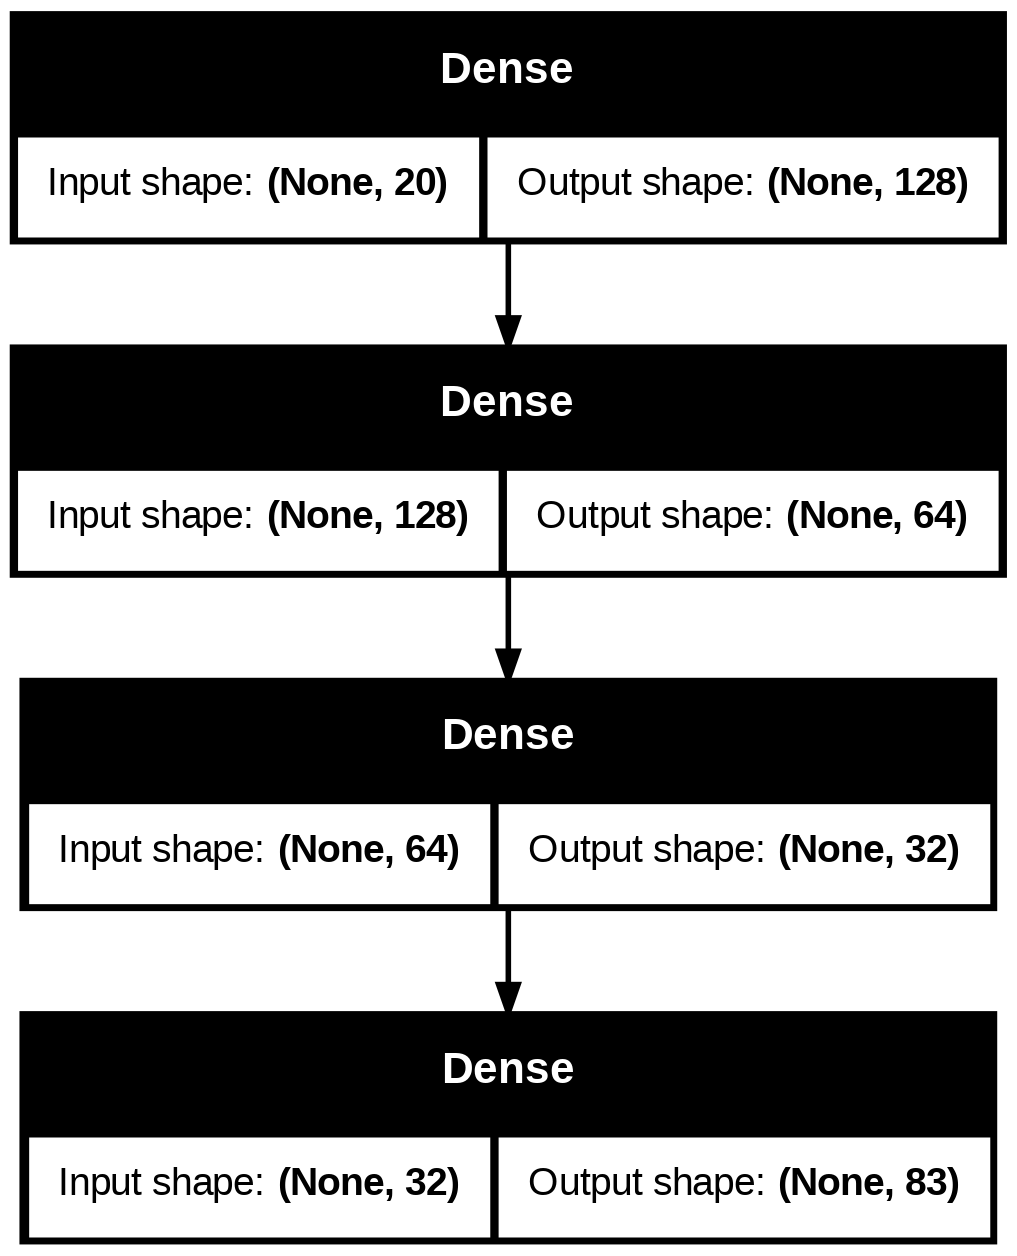

In [23]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [24]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.0405 - loss: 3.8095 - val_accuracy: 0.0866 - val_loss: 2.9393
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.2579 - loss: 2.3325 - val_accuracy: 0.3461 - val_loss: 1.6318
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4680 - loss: 1.5545 - val_accuracy: 0.4537 - val_loss: 1.4121
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5568 - loss: 1.3711 - val_accuracy: 0.5772 - val_loss: 1.2227
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6264 - loss: 1.1838 - val_accuracy: 0.6703 - val_loss: 1.0697
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6639 - loss: 1.0499 - val_accuracy: 0.5742 - val_loss: 0.9811
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7064 - loss: 1.0107 - val_accuracy: 0.7076 - val_loss: 0.8905
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7364 - loss: 0.908

# Evaluation

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9750 - loss: 0.1618
Akurasi Model: 0.9749
Loss Model: 0.1638


In [26]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

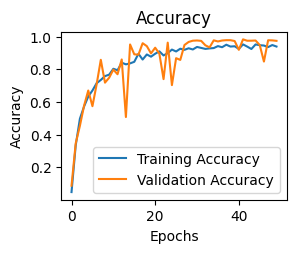

In [27]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

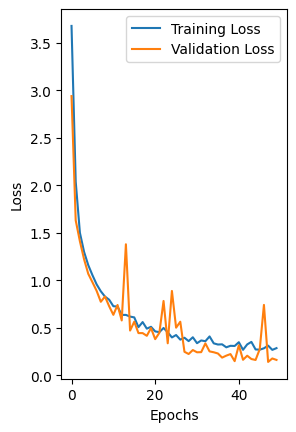

In [28]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


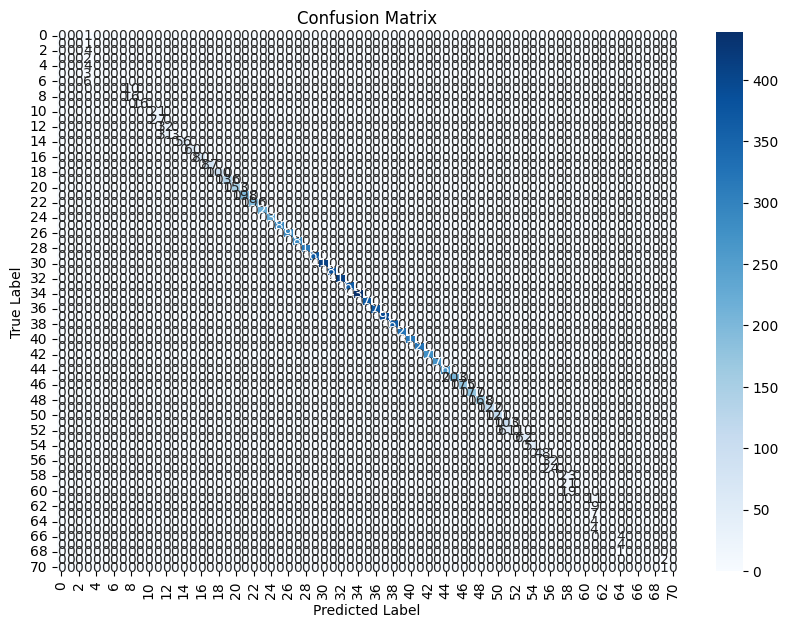

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         4
           7       0.10      1.00      0.17         2
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         6
          11       0.00      0.00      0.00        10
          12       0.62      1.00      0.76        16
          13       1.00      1.00      1.00        16
          14       0.00      0.00      0.00        21
          15       0.56      1.00      0.72        27
          16       0.51      1.00      0.67        32
          17       1.00      0.09      0.16        34
          18       1.00      1.00      1.00        56
          19       1.00      1.00      1.00        60
          20       1.00      1.00      1.00        80
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [30]:
sample_input = np.array([[1,2,3,4,5,6,7,8,9,1,2,3,4,5,6,7,8,9,1,2]])
sample_input_df = pd.DataFrame(sample_input)

In [31]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [32]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_flood = le.inverse_transform([predicted_class])

print(f"Flood Prediction: {predicted_flood[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Flood Prediction: 0.465


## Save Model

In [33]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('flood_prediction.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpauqrbbqo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 83), dtype=tf.float32, name=None)
Captures:
  136762901363984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901364560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901362832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901359376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901361488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901358032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901360336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136762901358992: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [34]:
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']